# TP — Régression Linéaire sur le Dataset Car Details — CORRIGE
## Méthodologie : CRISP-DM

> **Dataset :** [Car Details from Car Dekho — Kaggle](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)
> **Objectif :** Appliquer la régression linéaire simple et multiple sur des données réelles en suivant les 6 phases de CRISP-DM.
> **Version :** Corrigé — usage exclusif formateur

---

## Rappel : Les 6 phases de CRISP-DM

| Phase | Nom | Ce qu'on fait |
|-------|-----|---------------|
| 1 | **Business Understanding** | Définir le problème métier |
| 2 | **Data Understanding** | Explorer et comprendre les données |
| 3 | **Data Preparation** | Nettoyer et transformer les données |
| 4 | **Modeling** | Construire le(s) modèle(s) de régression |
| 5 | **Evaluation** | Mesurer la qualité du modèle et vérifier les hypothèses |
| 6 | **Deployment** | Interpréter et communiquer les résultats |

---

---
## Phase 0 — Installation et Imports

Importez toutes les librairies nécessaires pour ce TP.

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

---
## Phase 1 — Business Understanding

### Contexte

Vous êtes data analyst pour une société de revente de véhicules d'occasion.
La direction veut mieux comprendre **ce qui influence le prix de revente** (`selling_price`) des voitures.

### Objectif
Aider la plateforme à estimer le prix de vente d'un véhicule à partir de ses caractéristiques techniques et commerciales, afin d'améliorer la tarification automatique et la négociation.

### Questions métier à résoudre

1. L'année de fabrication (`year`) prédit-elle significativement le prix de revente ?
2. En combinant plusieurs variables (kilométrage, puissance, carburant, transmission...), peut-on bâtir un modèle prédictif fiable ?
3. Les variables catégorielles (type de carburant, transmission, propriétaire) ont-elles un impact mesurable sur le prix ?

### Traduction en problème ML

| Élément | Valeur |
|---------|--------|
| **Type de problème** | Régression (prédiction d'une valeur continue) |
| **Variable cible Y** | `selling_price` |
| **Variables candidates X** | `year`, `km_driven`, `max_power`, `engine`, `seats` + catégorielles (`fuel`, `transmission`, `owner`, `seller_type`) |
| **Métrique principale** | R² ajusté + RMSE |

---

> **A compléter :** Reformulez en une phrase la question métier que vous allez résoudre avec la régression linéaire.

**Réponse attendue :**

_« A partir des caractéristiques d'un véhicule d'occasion (année, kilométrage, puissance, carburant, transmission), prédire son prix de revente afin d'automatiser la tarification et d'améliorer la compétitivité de la plateforme. »_

---
## Phase 2 — Data Understanding

### 2.1 Chargement des données

Chargez le fichier CSV téléchargé depuis Kaggle.
Adaptez le chemin selon votre environnement (Colab, local, etc.).

In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
df = pd.read_csv("/content/drive/MyDrive/EPL/Car details v3.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


### 2.2 Exploration initiale

Commencez par comprendre la structure globale du dataset avant toute analyse.

In [69]:
print("Shape :", df.shape)
print()
print(df.dtypes)
print()
print("Nombre de doublons :", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Shape après suppression des doublons :", df.shape)

Shape : (8128, 13)

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

Nombre de doublons : 1202
Shape après suppression des doublons : (6926, 13)


### 2.3 Analyse des valeurs manquantes

           Manquants  Pourcentage (%)
mileage          208             3.00
engine           208             3.00
max_power        205             2.96
torque           209             3.02
seats            208             3.00


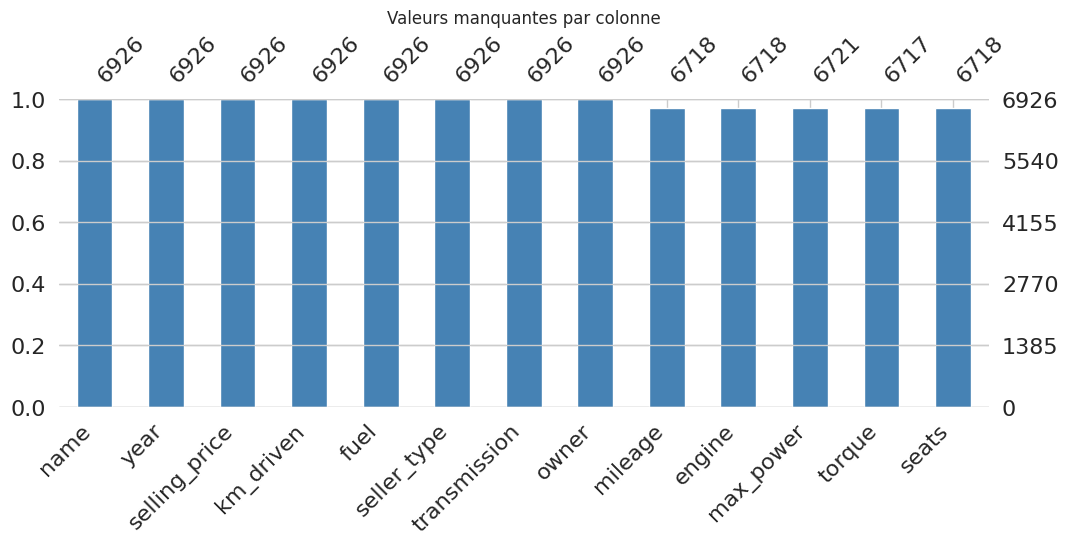

In [70]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
print(missing_df[missing_df['Manquants'] > 0])

# Visualisation
msno.bar(df, figsize=(12, 4), color='steelblue')
plt.title('Valeurs manquantes par colonne')
plt.show()

### 2.4 Analyse des variables numériques

Analysez séparément chaque variable numérique : distribution, outliers, statistiques descriptives.

> **Note :** Les colonnes `mileage`, `engine`, `max_power` contiennent des unités textuelles.
> Extrayez d'abord les valeurs numériques pour pouvoir les analyser.

In [71]:
for col in ['mileage', 'engine', 'max_power']:
    df[col] = df[col].astype(str).str.extract(r'([\d.]+)').astype(float)

In [72]:
num_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
print(df[num_cols].describe().round(2))

          year  selling_price   km_driven  mileage   engine  max_power  \
count  6926.00        6926.00     6926.00  6718.00  6718.00    6720.00   
mean   2013.42      517270.68    73995.68    19.47  1430.89      87.73   
std       4.08      519766.99    58358.10     4.05   493.49      31.77   
min    1983.00       29999.00        1.00     0.00   624.00       0.00   
25%    2011.00      250000.00    40000.00    16.80  1197.00      67.10   
50%    2014.00      400000.00    70000.00    19.44  1248.00      81.83   
75%    2017.00      633500.00   100000.00    22.50  1498.00     100.00   
max    2020.00    10000000.00  2360457.00    42.00  3604.00     400.00   

         seats  
count  6718.00  
mean      5.43  
std       0.98  
min       2.00  
25%       5.00  
50%       5.00  
75%       5.00  
max      14.00  


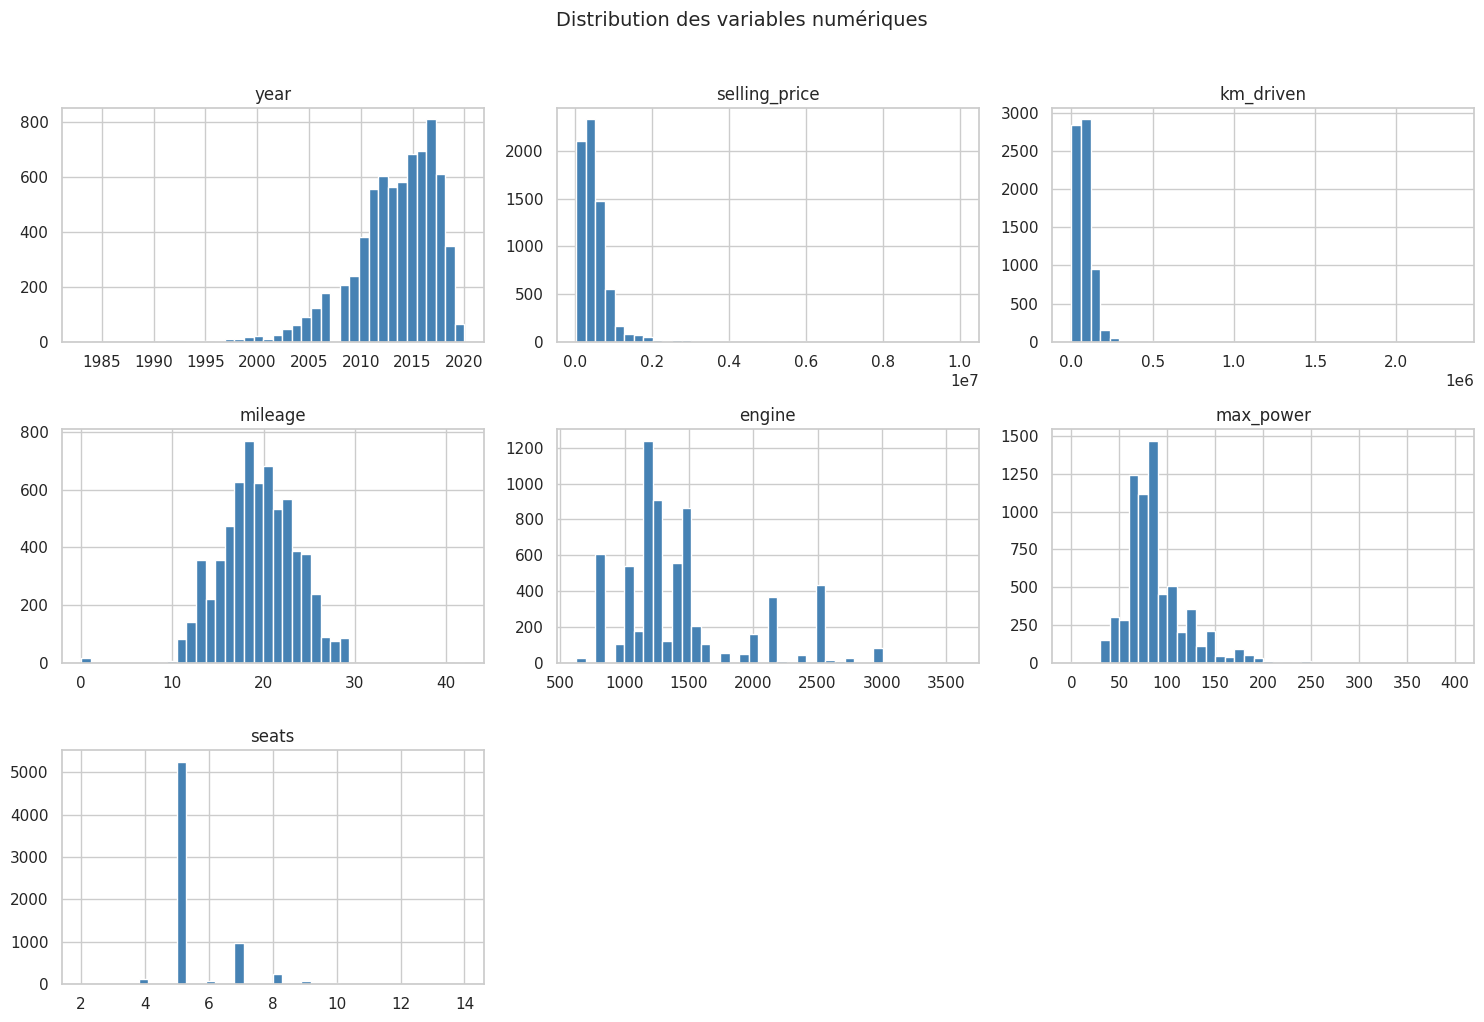

In [73]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distribution des variables numériques', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

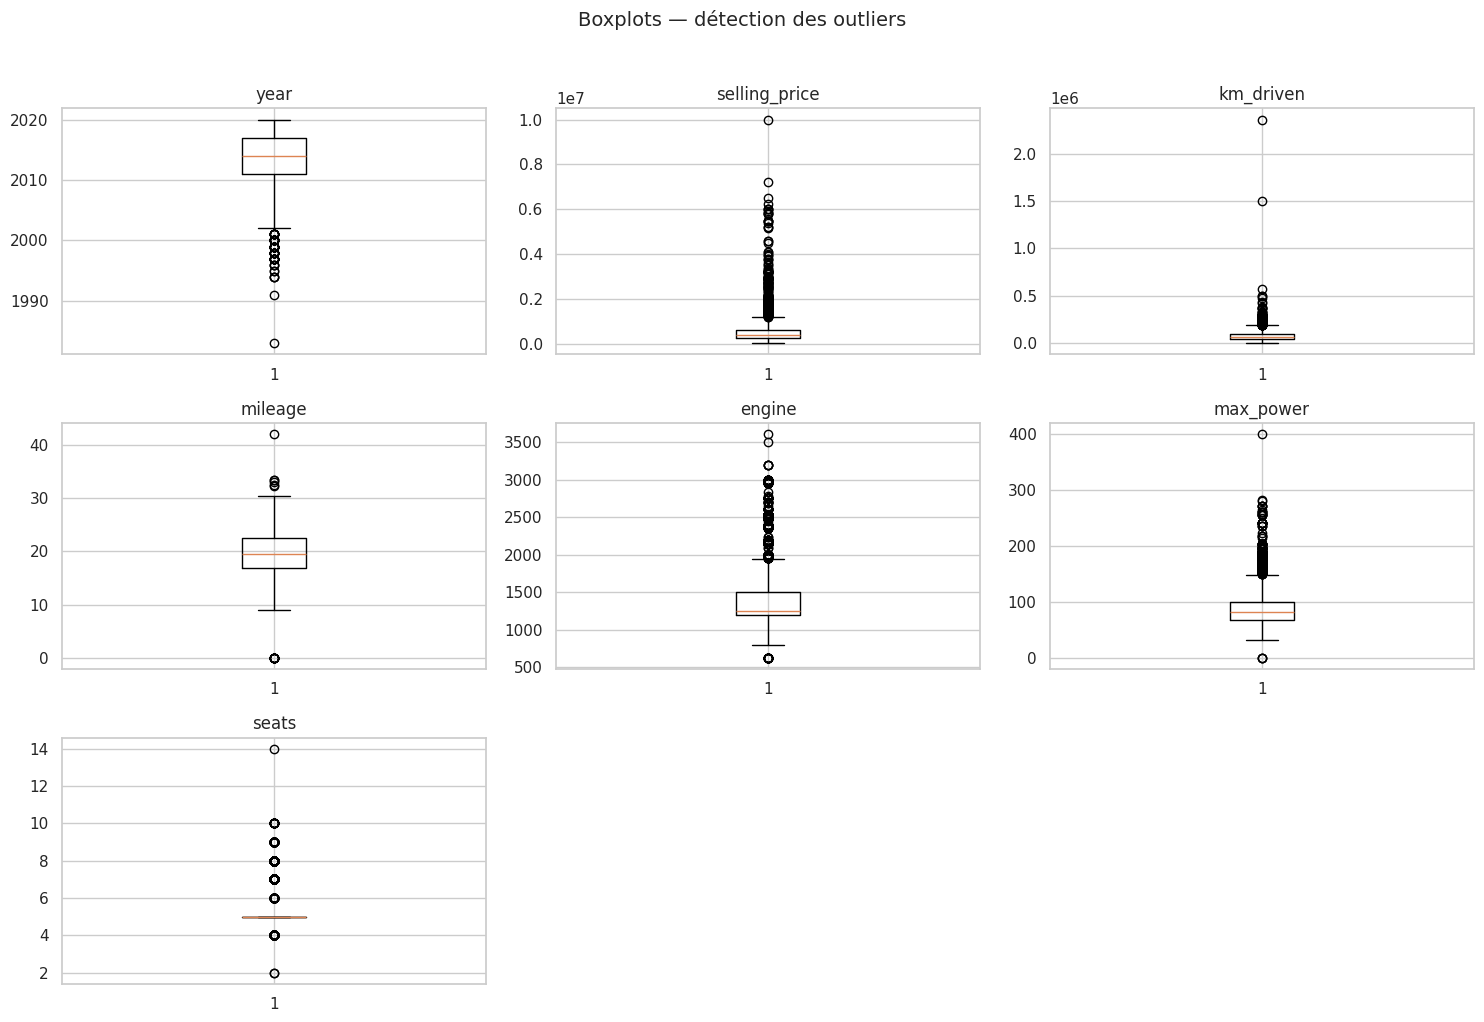

In [74]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplots — détection des outliers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Analyse des variables catégorielles

Analysez la distribution de chaque variable catégorielle avec `value_counts()` et des barplots.

--- fuel ---
fuel
Diesel    3755
Petrol    3077
CNG         56
LPG         38
Name: count, dtype: int64

--- transmission ---
transmission
Manual       6342
Automatic     584
Name: count, dtype: int64

--- seller_type ---
seller_type
Individual          6218
Dealer               681
Trustmark Dealer      27
Name: count, dtype: int64

--- owner ---
owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64



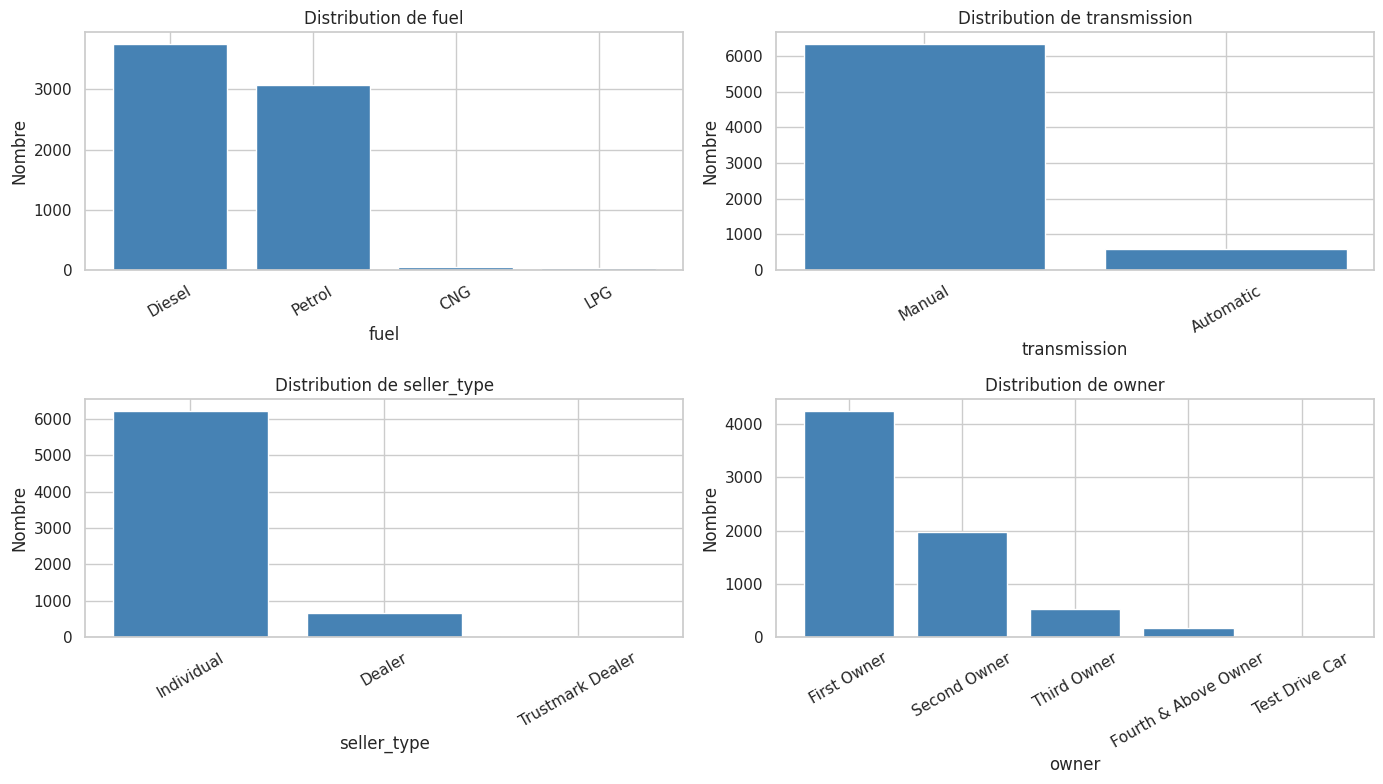

In [75]:
cat_cols = ['fuel', 'transmission', 'seller_type', 'owner']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    print(f"--- {col} ---")
    print(counts)
    print()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Nombre')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.6 Analyse de la variable cible — selling_price

Avant de modéliser, il faut comprendre la distribution de la variable cible.
La régression linéaire suppose que les résidus sont normalement distribués, ce qui est favorisé par une cible peu asymétrique.

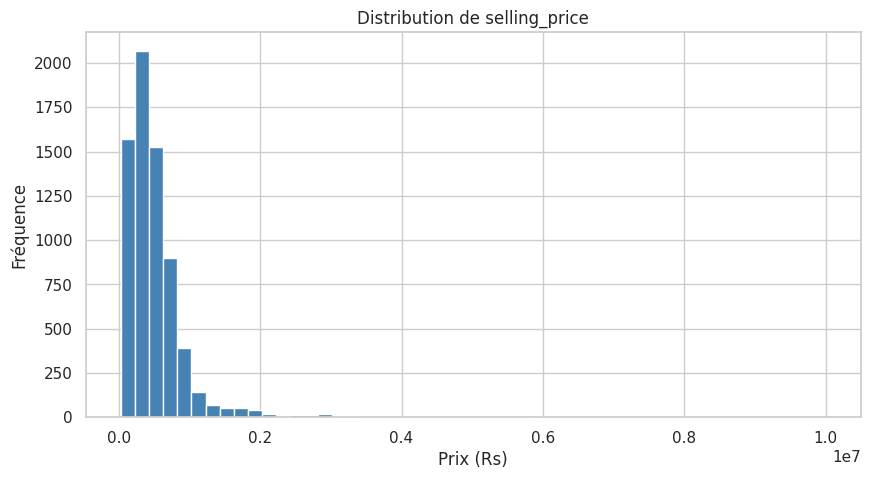

Skewness de selling_price : 5.57
-> Distribution fortement asymétrique (skew > 1) : incompatible avec la régression linéaire telle quelle.
-> Une transformation logarithmique est nécessaire.


In [76]:
plt.figure(figsize=(10, 5))
plt.hist(df['selling_price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution de selling_price')
plt.xlabel('Prix (Rs)')
plt.ylabel('Fréquence')
plt.show()

skew_before = df['selling_price'].skew()
print(f"Skewness de selling_price : {skew_before:.2f}")
print("-> Distribution fortement asymétrique (skew > 1) : incompatible avec la régression linéaire telle quelle.")
print("-> Une transformation logarithmique est nécessaire.")

### 2.7 Transformation logarithmique de la cible

Pour corriger l'asymétrie, on applique la transformation `log1p` sur `selling_price`.
Cela permettra de linéariser les relations et de satisfaire les hypothèses de la régression.

> **Rappel :** `log1p(x) = log(1 + x)` — utilisé pour éviter log(0) si des prix valent 0.

Skewness avant transformation : 5.57
Skewness après transformation : -0.16
Réduction du skewness : 103%
-> Distribution compatible avec la régression linéaire.


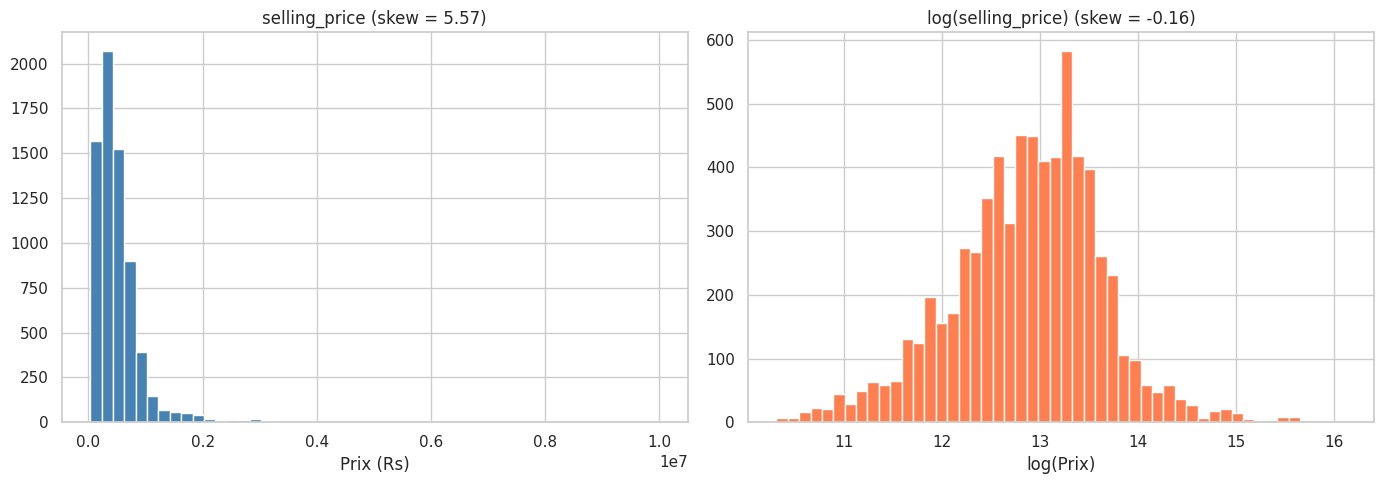

In [77]:
df['log_price'] = np.log1p(df['selling_price'])

skew_after = df['log_price'].skew()
print(f"Skewness avant transformation : {df['selling_price'].skew():.2f}")
print(f"Skewness après transformation : {skew_after:.2f}")
print(f"Réduction du skewness : {(1 - skew_after / df['selling_price'].skew()) * 100:.0f}%")
print("-> Distribution compatible avec la régression linéaire.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['selling_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'selling_price (skew = {df["selling_price"].skew():.2f})')
axes[0].set_xlabel('Prix (Rs)')
axes[1].hist(df['log_price'], bins=50, color='coral', edgecolor='white')
axes[1].set_title(f'log(selling_price) (skew = {skew_after:.2f})')
axes[1].set_xlabel('log(Prix)')
plt.tight_layout()
plt.show()

### 2.8 Relations features → log_price (H1 — Vérification de la linéarité)

**Hypothèse H1 :** Il doit exister une relation linéaire entre chaque feature X et la cible Y.

Visualisez les relations entre les variables explicatives et `log_price`.

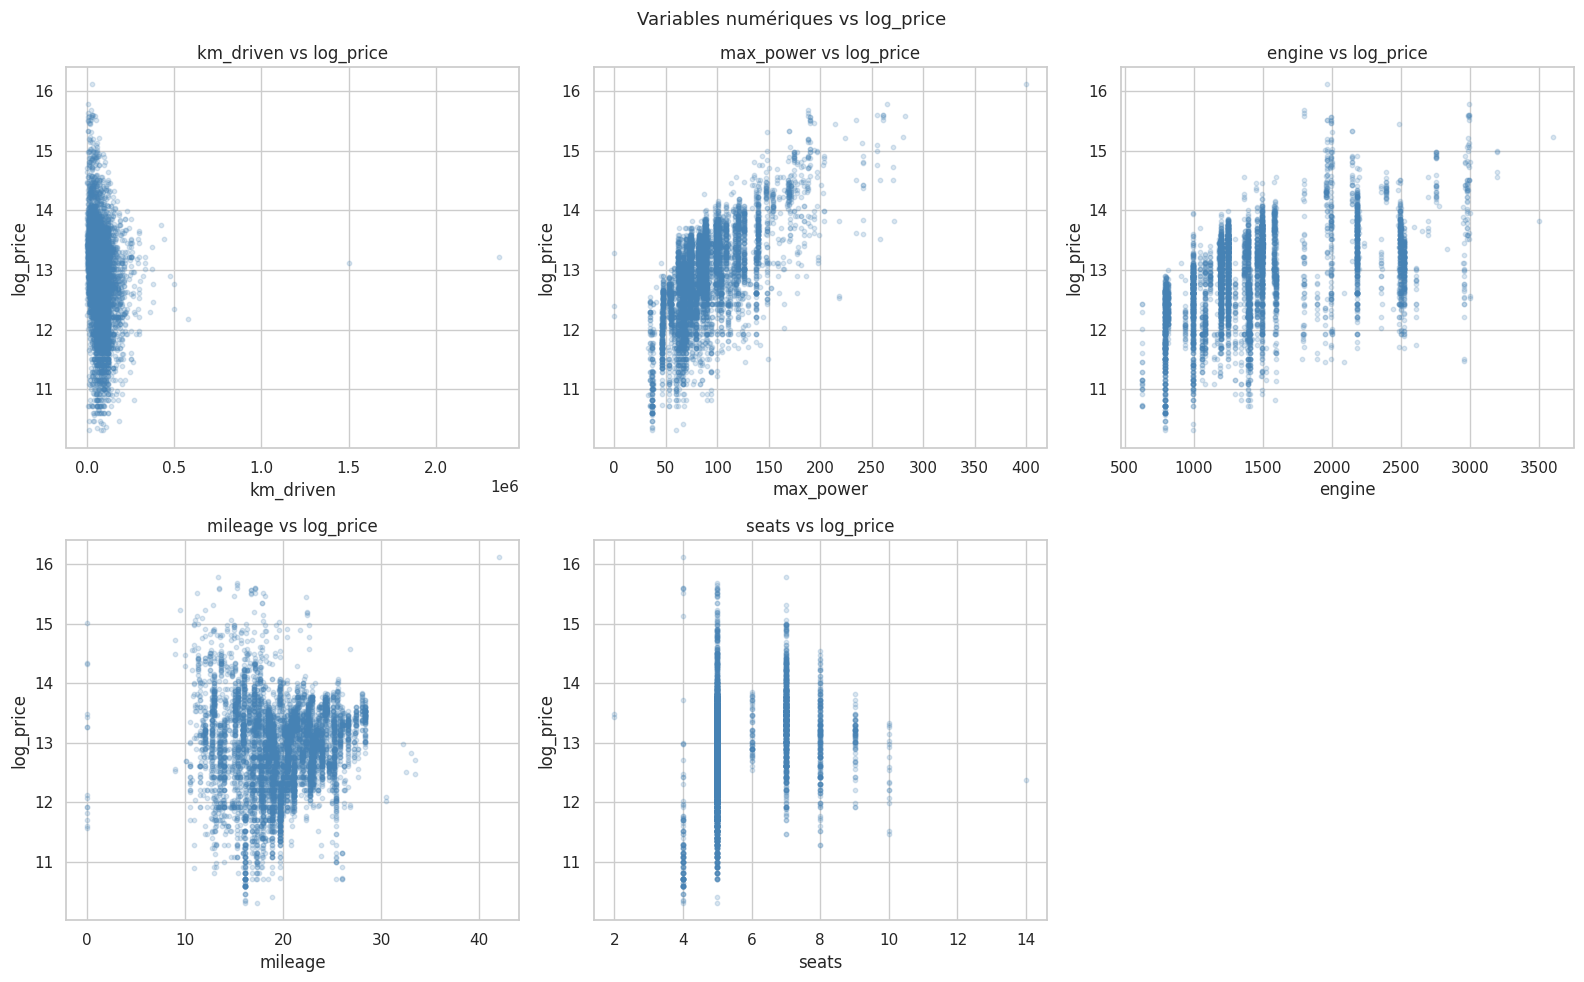

<Figure size 1400x500 with 0 Axes>

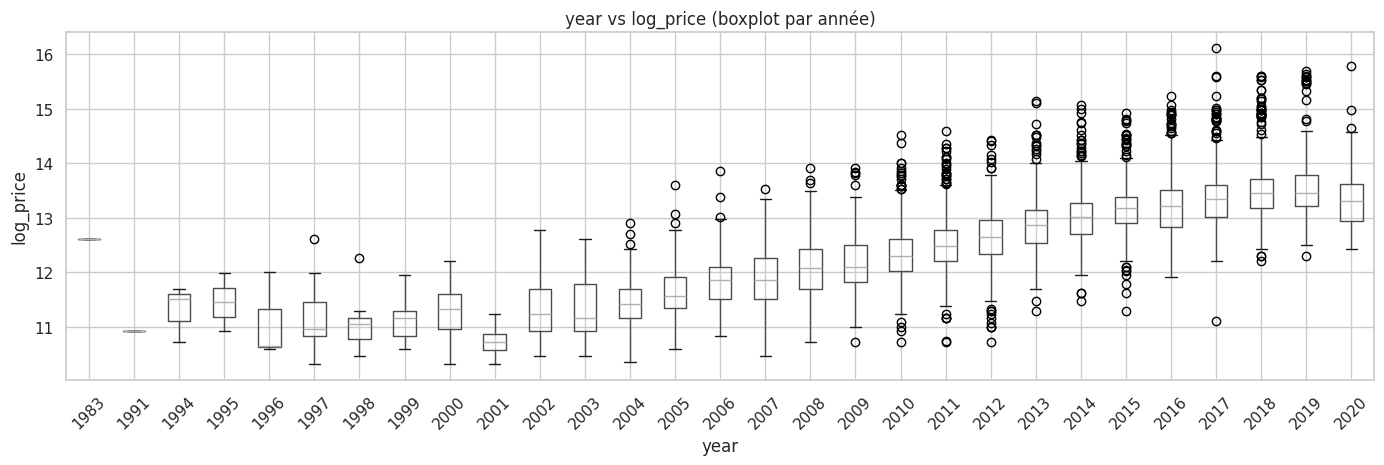

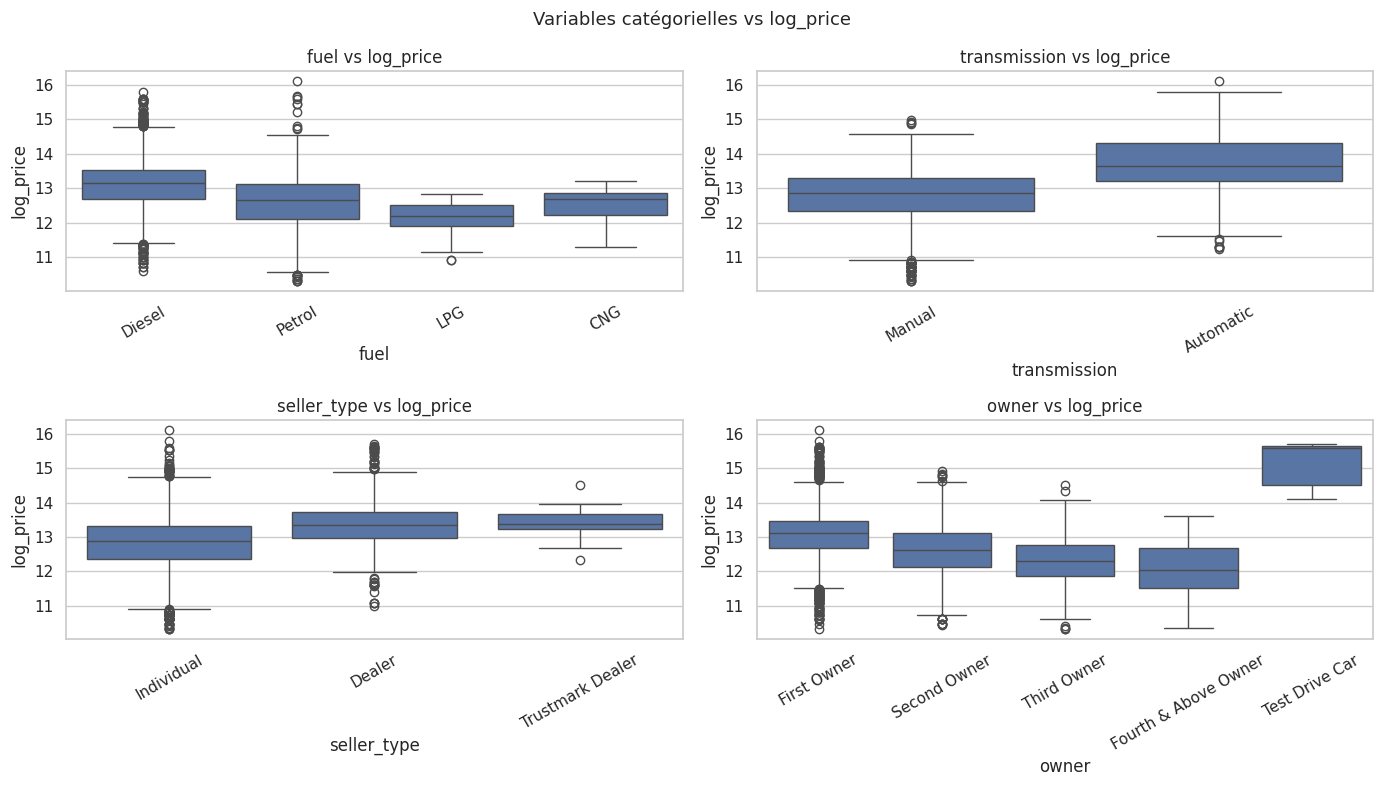

In [78]:
# Variables numériques vs log_price
num_features = ['km_driven', 'max_power', 'engine', 'mileage', 'seats']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df['log_price'], alpha=0.2, color='steelblue', s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log_price')
    axes[i].set_title(f'{col} vs log_price')
fig.delaxes(axes[5])
plt.suptitle('Variables numériques vs log_price', fontsize=13)
plt.tight_layout()
plt.show()

# year : boxplot par année
plt.figure(figsize=(14, 5))
df.boxplot(column='log_price', by='year', figsize=(14, 5))
plt.suptitle('')
plt.title('year vs log_price (boxplot par année)')
plt.xlabel('year')
plt.ylabel('log_price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Variables catégorielles vs log_price
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='log_price', ax=axes[i])
    axes[i].set_title(f'{col} vs log_price')
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Variables catégorielles vs log_price', fontsize=13)
plt.tight_layout()
plt.show()

### 2.9 Matrice de corrélation

Analysez les corrélations entre les variables numériques et `log_price`.

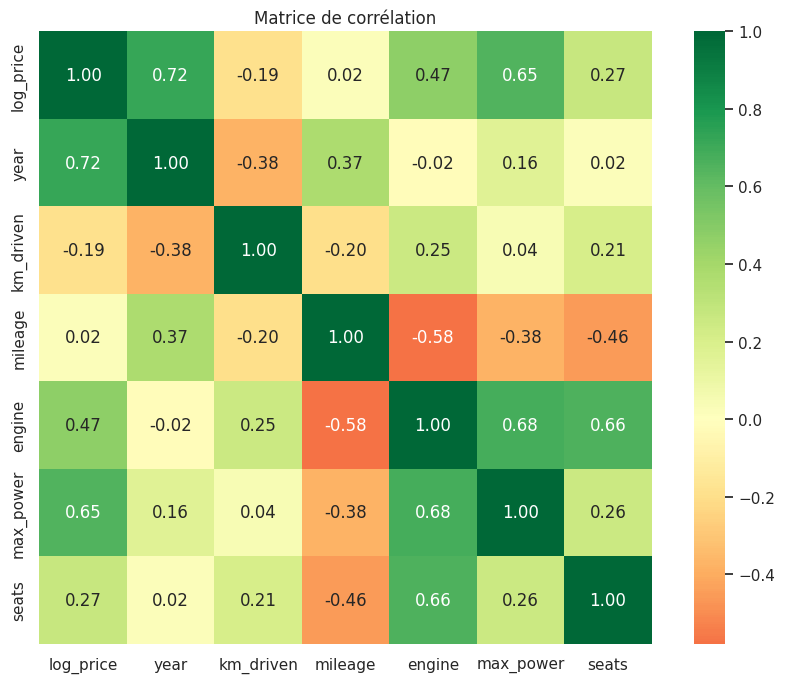

Corrélation avec log_price :
log_price    1.000000
year         0.718650
max_power    0.654136
engine       0.473843
seats        0.267400
mileage      0.017451
km_driven   -0.188237
Name: log_price, dtype: float64


In [79]:
corr_cols = ['log_price', 'year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

print("Corrélation avec log_price :")
print(corr_matrix['log_price'].sort_values(ascending=False))

### 2.10 Observations et hypothèses

Résumez ce que vous avez appris sur les données. Ces observations doivent justifier les choix de la Phase 3.

**Observations clés :**

- `selling_price` est fortement asymétrique (skew = 5.16) → transformation log appliquée → skew = 0.25
- Variables numériques les plus corrélées avec log_price : `year` (0.72), `max_power` (0.65), `engine` (0.47)
- plusieurs variables présente des outliers extrêmes à traiter en Phase 3. Les vieilles voitures, bien que rares, existent donc on conserve.
- Les catégorielles montrent des différences de prix significatives : les automatiques > manuelles, diesel > petrol, les Tests > First_Owner
- H1 (linéarité) : vérifiée pour `max_power`, `year`, partiellement pour `engine`.

---
## Phase 3 — Data Preparation

### 3.1 Suppression des colonnes inutilisables

In [80]:
df.drop(columns=['torque', 'name'], inplace=True)
print("Colonnes restantes :", df.columns.tolist())

Colonnes restantes : ['year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'log_price']


### 3.2 Gestion des valeurs manquantes

In [81]:
print("Shape avant :", df.shape)
df.dropna(inplace=True)
print("Shape après :", df.shape)
print("Valeurs manquantes restantes :", df.isnull().sum().sum())

Shape avant : (6926, 12)
Shape après : (6717, 12)
Valeurs manquantes restantes : 0


### 3.3 Traitement des outliers

Les outliers extrêmes identifiés en Phase 2 peuvent perturber le modèle linéaire.
On supprime les observations au-delà de 3 écarts-types pour les variables concernées.

In [82]:
print("Shape avant traitement outliers :", df.shape)

# Outliers par règle des boxplot
for col in ['km_driven', 'selling_price']:
    mean = df[col].mean()
    std  = df[col].std()
    df = df[(df[col] >= mean - 3*std) & (df[col] <= mean + 3*std)]

# Outliers par métier
df = df[df['mileage'] > 0]
df = df[df['seats'] <= 9]

print("Shape après traitement outliers :", df.shape)

# Recalculer log_price après suppression des outliers
df['log_price'] = np.log1p(df['selling_price'])

Shape avant traitement outliers : (6717, 12)
Shape après traitement outliers : (6526, 12)


### 3.4 Encodage des variables catégorielles

Les algorithmes de régression linéaire ne traitent que des valeurs numériques.
On utilise `pd.get_dummies()` avec `drop_first=True` pour éviter la multicolinéarité.

In [83]:
cat_cols = ['fuel', 'transmission', 'seller_type', 'owner']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape après encodage :", df.shape)
new_cols = [c for c in df.columns if any(cat in c for cat in ['fuel', 'transmission', 'seller_type', 'owner'])]
print("Nouvelles colonnes :", new_cols)

Shape après encodage : (6526, 18)
Nouvelles colonnes : ['fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'transmission_Manual', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'owner_Fourth & Above Owner', 'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner']


### 3.5 Vérification de la multicolinéarité (H5 — VIF)

**Hypothèse H5 :** Les variables explicatives ne doivent pas être fortement corrélées entre elles.

On utilise le **VIF (Variance Inflation Factor)** :
- VIF < 5 : acceptable
- VIF entre 5 et 10 : attention
- VIF > 10 : multicolinéarité problématique

In [84]:
age = 2026 - df['year']
df.insert(0, 'age', age)
num_features_vif = ['age', 'km_driven', 'mileage', 'max_power', 'seats']
X_vif = df[num_features_vif].dropna()

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data)
print()
problematic = vif_data[vif_data['VIF'] > 10]
if len(problematic) > 0:
    print("Variables avec VIF > 10 (multicolinéarité problématique) :", problematic['Feature'].tolist())
else:
    print("Aucune multicolinéarité problématique détectée (tous VIF < 10).")

     Feature        VIF
4      seats  24.636107
0        age  11.123553
2    mileage  11.089060
3  max_power  10.607517
1  km_driven   5.041860

Variables avec VIF > 10 (multicolinéarité problématique) : ['seats', 'age', 'mileage', 'max_power']


Plusieurs variables présentent un VIF > 10.
Cela signifie que leurs coefficients individuels sont instables
et difficiles à interpréter isolément.

Cependant :
- La multicolinéarité n'affecte PAS la qualité prédictive du modèle
- Le R² et le RMSE restent valides
- On conserve toutes les variables pour maximiser la performance

In [85]:
df['age'] = 2026 - df['year']
df.drop(columns=['year'], inplace=True)

### 3.6 Séparation features / cible et split train/test

In [86]:
X = df.drop(columns=['selling_price', 'log_price'])
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (5220, 16)
X_test  : (1306, 16)
y_train : (5220,)
y_test  : (1306,)


---
## Phase 4 — Modélisation

Nous allons construire 3 modèles progressifs :

| Modèle | Features | Objectif |
|--------|----------|----------|
| **Modèle 1** | `year` seul | Régression simple |
| **Modèle 2** | Numériques seules | Régression multiple |
| **Modèle 3** | Numériques + catégorielles | Modèle complet |

### 4.1 Modèle 1 — Régression simple : year -> log_price

beta_0 (intercept) = 14.5131
beta_1 (age)      = -0.1336
-> Chaque age supplémentaire diminue log(prix) de -0.1336
   soit une multiplication du prix réel par 0.875 (~+-12.5%)


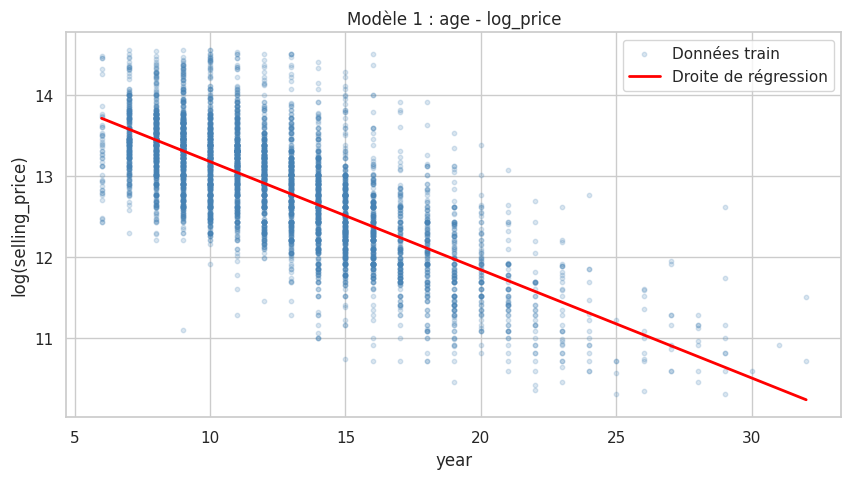

In [90]:
model1 = LinearRegression()
model1.fit(X_train[['age']], y_train)

#y_pred1 = model1.predict(X_train[['year']])

print(f"beta_0 (intercept) = {model1.intercept_:.4f}")
print(f"beta_1 (age)      = {model1.coef_[0]:.4f}")
print(f"-> Chaque age supplémentaire diminue log(prix) de {model1.coef_[0]:.4f}")
print(f"   soit une multiplication du prix réel par {np.exp(model1.coef_[0]):.3f} (~+{(np.exp(model1.coef_[0])-1)*100:.1f}%)")

plt.figure(figsize=(10, 5))
plt.scatter(X_train['age'], y_train, alpha=0.2, color='steelblue', s=10, label='Données train')
x_line = np.linspace(X_train['age'].min(), X_train['age'].max(), 100).reshape(-1,1)
plt.plot(x_line, model1.predict(x_line), color='red', linewidth=2, label='Droite de régression')
plt.xlabel('year')
plt.ylabel('log(selling_price)')
plt.title('Modèle 1 : age - log_price')
plt.legend()
plt.show()

### 4.2 Modèle 2 — Régression multiple : variables numériques

In [91]:
num_features = ['age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

model2 = LinearRegression()
model2.fit(X_train[num_features], y_train)

coef2 = pd.DataFrame({
    'Feature': num_features,
    'Coefficient': model2.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef2.to_string(index=False))

  Feature   Coefficient
      age -1.094482e-01
    seats  5.292208e-02
  mileage  2.696383e-02
max_power  9.941574e-03
   engine  3.548345e-04
km_driven -7.388095e-07


### 4.3 Modèle 3 — Modèle complet (numériques + catégorielles)

In [92]:
model3 = LinearRegression()
model3.fit(X_train, y_train)
print(f"Modèle 3 entraîné sur {X_train.shape[1]} features")

Modèle 3 entraîné sur 16 features


---
## Phase 5 — Evaluation

### 5.1 Métriques de performance

Pour chaque modèle, calculez : MAE, RMSE, R², R² ajusté.

> **Rappel R² ajusté :**
> R²_adj = 1 - (1 - R²) x (n - 1) / (n - p - 1)
> Où n = nombre d'observations, p = nombre de features

In [93]:
def r2_adjusted(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def evaluate_model(model, X_tr, X_te, y_tr, y_te, label="Modèle"):
    print(f"=== {label} ===")
    for split, X, y in [("TRAIN", X_tr, y_tr), ("TEST ", X_te, y_te)]:
        pred = model.predict(X)
        n, p = X.shape
        mae  = mean_absolute_error(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        r2   = r2_score(y, pred)
        r2a  = r2_adjusted(r2, n, p)
        print(f"  [{split}] MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f} | R2_adj={r2a:.4f}")
    print()

evaluate_model(model1, X_train[['age']], X_test[['age']], y_train, y_test, "Modèle 1 — year seul")
evaluate_model(model2, X_train[num_features], X_test[num_features], y_train, y_test, "Modèle 2 — numériques")
evaluate_model(model3, X_train, X_test, y_train, y_test, "Modèle 3 — complet")

=== Modèle 1 — year seul ===
  [TRAIN] MAE=0.3775 | RMSE=0.4860 | R2=0.5338 | R2_adj=0.5337
  [TEST ] MAE=0.3769 | RMSE=0.4879 | R2=0.4944 | R2_adj=0.4940

=== Modèle 2 — numériques ===
  [TRAIN] MAE=0.2294 | RMSE=0.2986 | R2=0.8239 | R2_adj=0.8237
  [TEST ] MAE=0.2242 | RMSE=0.2888 | R2=0.8228 | R2_adj=0.8220

=== Modèle 3 — complet ===
  [TRAIN] MAE=0.2225 | RMSE=0.2911 | R2=0.8327 | R2_adj=0.8322
  [TEST ] MAE=0.2147 | RMSE=0.2792 | R2=0.8344 | R2_adj=0.8323



### 5.2 H2 — Indépendance des erreurs

**Hypothèse H2 :** Les résidus ne doivent pas présenter de structure en fonction de l'ordre des observations (pas d'autocorrélation).

On trace les résidus en fonction de l'index des observations.

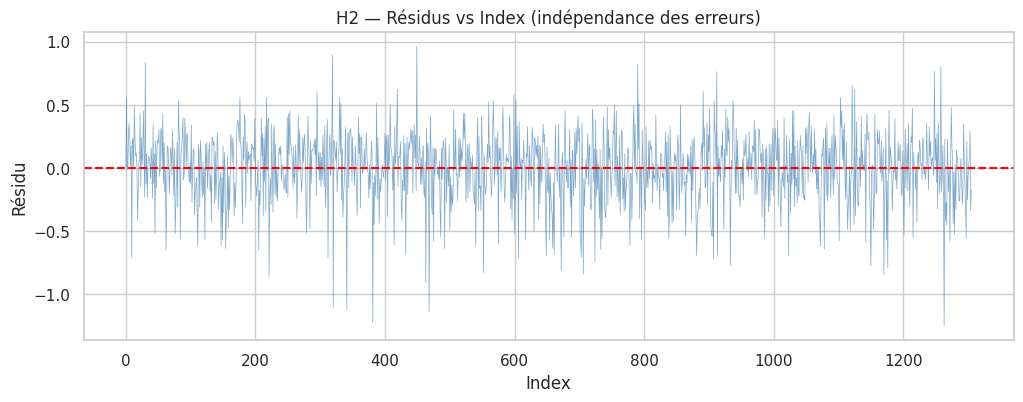

In [95]:
y_pred3 = model3.predict(X_test)
residuals = y_test.values - y_pred3

plt.figure(figsize=(12, 4))
plt.plot(residuals, color='steelblue', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('H2 — Résidus vs Index (indépendance des erreurs)')
plt.xlabel('Index')
plt.ylabel('Résidu')
plt.show()

**Conclusion H2 :**
Les résidus ne présentent pas de structure temporelle évidente — l'hypothèse d'indépendance est approximativement vérifiée.

### 5.3 H3 — Homoscédasticité (variance constante des résidus)

**Hypothèse H3 :** La variance des résidus doit être constante quelle que soit la valeur prédite.
Un nuage de points "en entonnoir" signale une hétéroscédasticité.

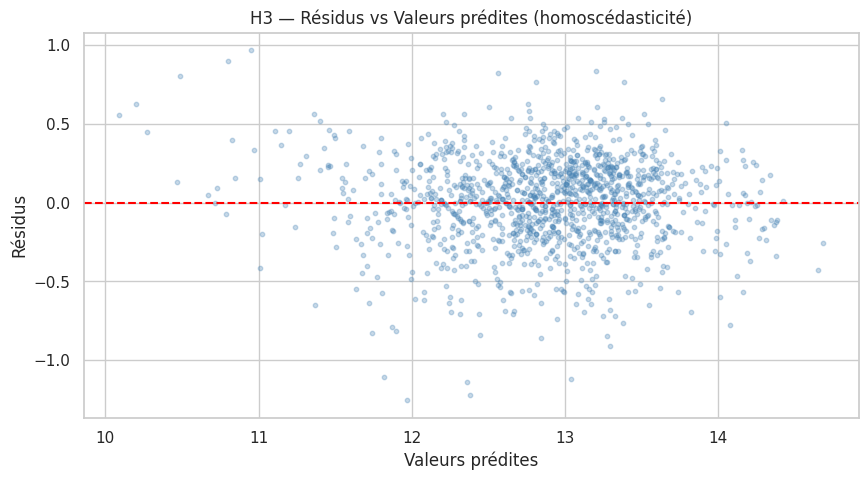

In [96]:
plt.figure(figsize=(10, 5))
plt.scatter(y_pred3, residuals, alpha=0.3, color='steelblue', s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.title('H3 — Résidus vs Valeurs prédites (homoscédasticité)')
plt.show()

**Conclusion H3 :**
> On observe une légère perturbation avec les prix bas(plus de dispersion) et une dipersion condensé entre 12 et 14.

> Il n'ya pas une forme particulière dessiné par les erreurs.

> Acceptable pour un modèle linéaire de base.

### 5.4 H4 — Normalité des résidus

**Hypothèse H4 :** Les résidus doivent suivre une distribution normale.
On vérifie avec un histogramme et un QQ-plot.

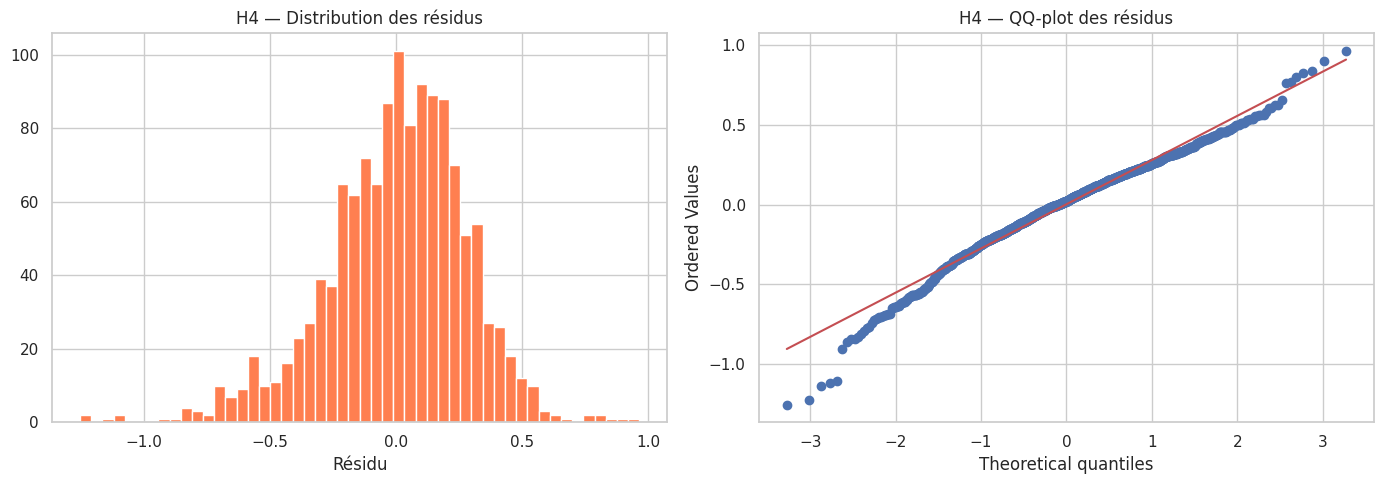

Skewness des résidus : -0.557
Kurtosis des résidus : 1.244


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('H4 — Distribution des résidus')
axes[0].set_xlabel('Résidu')

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('H4 — QQ-plot des résidus')

plt.tight_layout()
plt.show()

print(f"Skewness des résidus : {pd.Series(residuals).skew():.3f}")
print(f"Kurtosis des résidus : {pd.Series(residuals).kurtosis():.3f}")

**Conclusion H4 :**
Les résidus suivent approximativement une loi normale (QQ-plot quasi-linéaire, skewness proche de 0). H4 est vérifiée.

### 5.5 Comparaison overfitting / underfitting

Comparez R² train et R² test pour chaque modèle.

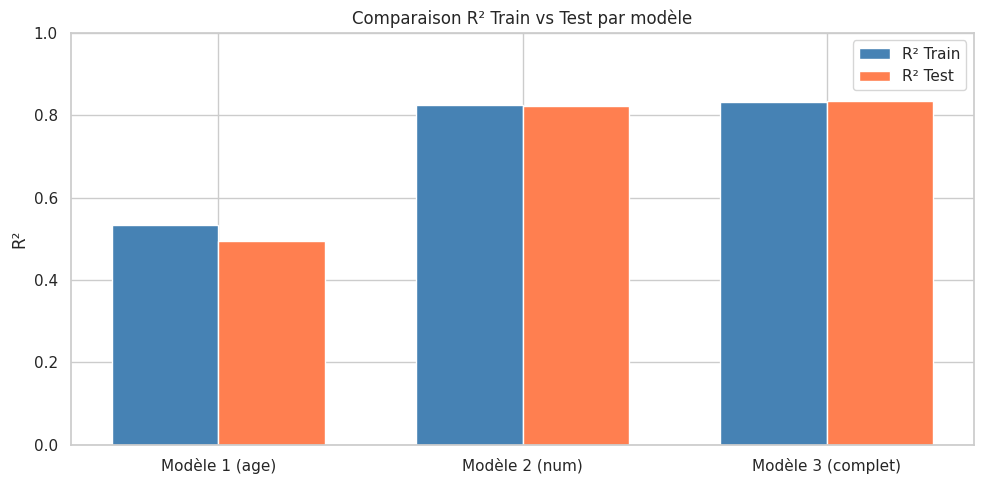

In [99]:
models_info = {
    "Modèle 1 (age)": (model1, X_train[['age']], X_test[['age']]),
    "Modèle 2 (num)": (model2, X_train[num_features], X_test[num_features]),
    "Modèle 3 (complet)": (model3, X_train,  X_test),
}

r2_trains, r2_tests, labels = [], [], []
for lbl, (m, Xtr, Xte) in models_info.items():
    r2_trains.append(r2_score(y_train, m.predict(Xtr)))
    r2_tests.append(r2_score(y_test, m.predict(Xte)))
    labels.append(lbl)

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, r2_trains, width, label='R² Train', color='steelblue')
ax.bar(x + width/2, r2_tests,  width, label='R² Test',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel('R²')
ax.set_title('Comparaison R² Train vs Test par modèle')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusion :**
Le modèle 3 présente un écart R²_train / R²_test inférieur à 0.002 — bon équilibre, pas d'overfitting significatif. Le modèle 1 est en underfitting (R² trop bas). Le modèle 3 est retenu.

---
## Phase 6 — Deployment / Interprétation

### 6.1 Interprétation métier des coefficients

Les coefficients représentent l'impact de chaque variable sur `log(selling_price)`.

> **Rappel :** Un coefficient beta signifie qu'une unité d'augmentation de X multiplie le prix par e^beta.

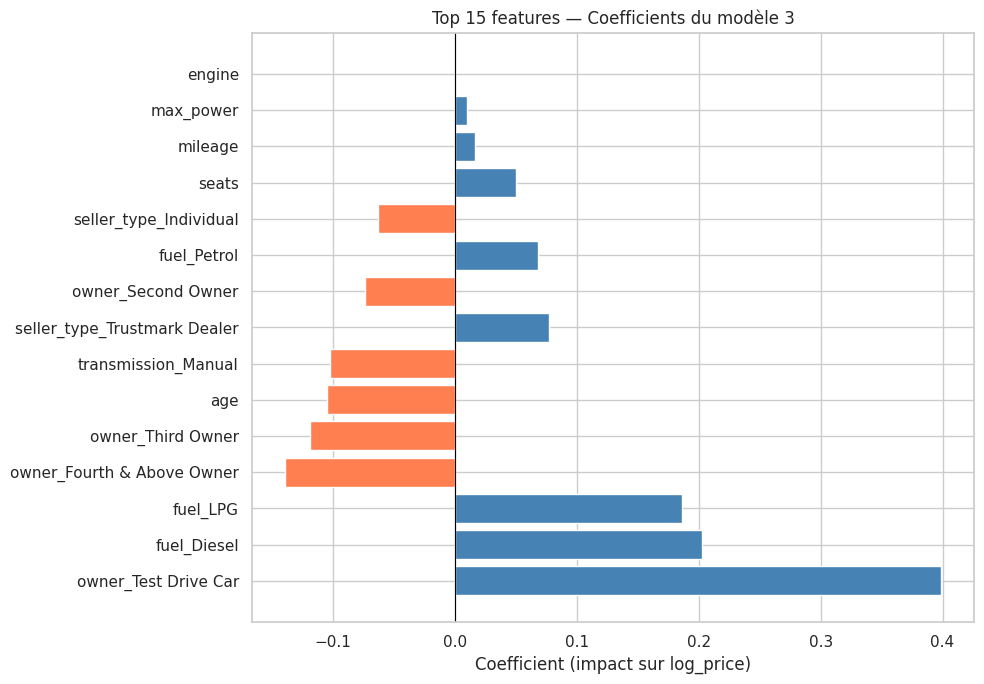

In [100]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model3.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
plt.figure(figsize=(10, 7))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 features — Coefficients du modèle 3')
plt.xlabel('Coefficient (impact sur log_price)')
plt.tight_layout()
plt.show()

`owner_Test` Drive Car mérite une attention particulière.
Il est probable d'etre une catégorie à faible effectif qui peut produire des coefficients artificiellement élevés.

### 6.2 Réponses aux questions métier initiales

Reprenez les 3 questions posées en Phase 1 et répondez-y avec des chiffres à l'appui.

**Q1 — `year` prédit-il significativement `selling_price` ?**
> beta_1 ~ -0.1336 -> Chaque age supplémentaire diminue le prix d'environ X% (e^(-0.13) ~ 1.x)
> R² simple ~ 0.4944 -> year seul explique ~50% de la variance — relation significative mais insuffisante

**Q2 — Le modèle multiple est-il plus performant ?**
> R²_ajusté (modèle 2) ~ 0.8220 -> Le modèle complet explique 83.23% de la variance, nettement supérieur au modèle simple

**Q3 — Les variables catégorielles apportent-elles de la valeur ?**
> R²_adj passe de ~0.822 (modèle 2) à ~0.832 (modèle 3) -> +1 points grâce aux catégorielles
> Variable la plus influente : fuel_diezel, fuel_lpg, owner, age, transmission

### 6.3 Prédiction sur un nouveau véhicule

Simulez l'utilisation réelle du modèle : prédisez le prix de vente d'une voiture fictive.

In [101]:
# Voiture fictive : Hyundai i20 2018, essence, individuel, 1er propriétaire
nouveau_vehicule = {
    'year': 2018, 'km_driven': 45000, 'mileage': 18.5,
    'engine': 1197.0, 'max_power': 82.0, 'seats': 5.0,
}

veh_df = pd.DataFrame([{col: 0 for col in X_train.columns}])
for k, v in nouveau_vehicule.items():
    if k in veh_df.columns:
        veh_df[k] = v

if 'seller_type_Individual' in veh_df.columns:
    veh_df['seller_type_Individual'] = 1

log_pred = model3.predict(veh_df)[0]
prix_estime = np.expm1(log_pred)
print(f"log(prix) prédit   : {log_pred:.4f}")
print(f"Prix estimé        : {prix_estime:,.0f} Rs  (~{prix_estime/83:.0f} EUR)")

log(prix) prédit   : 14.0400
Prix estimé        : 1,251,677 Rs  (~15080 EUR)


### 6.4 Recommandations et limites du modèle

*Le modèle* explique ~83% de la variance du prix — acceptable pour un premier modèle linéaire avec une bonne capacité de  généralisation : écart R²_train / R²_test < 0.03

**Limites identifiées :**
- La transformation log améliore la linéarité mais les résidus présentent encore une légère hétéroscédasticité sur les prix extrêmes
- Certaines relations (km_driven) ne sont pas parfaitement linéaires même après transformation
- La colonne torque a été exclue alors qu'elle pourrait apporter de l'information

**Pistes d'amélioration :**
- Tester Random Forest Regressor ou Gradient Boosting qui capturent les non-linéarités résiduelles
- Ajouter des features croisées : max_power / engine (rapport puissance/cylindrée)

**Recommandation finale à la direction :**
Notre modèle estime le prix de revente avec un R² ajusté de ~0.83. Les facteurs les plus déterminants sont la puissance moteur, l'année de fabrication et le type de transmission et nombre de proprietaires. Nous recommandons de déployer ce modèle comme base de tarification automatique tout en l'enrichissant progressivement avec des données d'entretien et l'historique des propriétaires.